# 01 - EDA : Analyse exploratoire et nettoyage (Telecom Churn)

**Objectif du notebook :** comprendre le dataset, corriger ses anomalies, puis analyser comment chaque variable est liée au churn.

| Partie | Contenu |
|---|---|
| A | Inspection des données brutes (types, NaN, doublons, valeurs cachées) |
| B | Nettoyage (`TotalCharges`, `customerID`, `Churn`) et sauvegarde du CSV propre |
| C | Analyse univariée (distributions, outliers) |
| D | Analyse bivariée (variables vs churn, corrélations) et pistes de Feature Engineering |

**Règle anti data leakage :** ce notebook est purement descriptif. Aucune transformation apprise sur les données (moyenne, médiane, scaler, SMOTE) n'est ajustée ici. Ces étapes viendront après le split train/test, dans des `Pipeline` (J3 et suivants).

# Partie A : Inspection des données brutes

**Pourquoi commencer par là ?** Avant de nettoyer ou de dessiner quoi que ce soit, on regarde les données *telles quelles*. Toute anomalie repérée ici (mauvais type, valeur cachée, doublon) déterminera le nettoyage de la Partie B.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import chi2_contingency

pd.set_option("display.max_columns", None)   # afficher les 21 colonnes
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# On teste deux emplacements possibles du CSV (data/raw/ ou data/)
CANDIDATES = [
    Path("../data/raw/wa-fn-usec-telco-customer-churn.csv"),
    Path("../data/wa-fn-usec-telco-customer-churn.csv"),
]
RAW_PATH = next((p for p in CANDIDATES if p.exists()), None)
if RAW_PATH is None:
    raise FileNotFoundError("CSV introuvable : vérifie le dossier data/")

PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
print("CSV utilisé :", RAW_PATH)

CSV utilisé : ../data/raw/wa-fn-usec-telco-customer-churn.csv


**Pourquoi ces choix ?**
- On n'utilise **pas** `warnings.filterwarnings("ignore")` : les avertissements de pandas/seaborn signalent souvent un vrai problème, les masquer serait risqué.
- `display.max_columns=None` : pandas cache les colonnes du milieu quand il y en a beaucoup ; on veut voir les 21.
- Le chemin est vérifié explicitement : un message clair vaut mieux qu'une erreur obscure.

## A.1 Chargement et aperçu

In [2]:
df = pd.read_csv(RAW_PATH)   # aucune option : on laisse pandas deviner les types
print("Dimensions :", df.shape)
df.head()

Dimensions : (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Pourquoi `read_csv` sans options ?** Si pandas devine un type inattendu pour une colonne, c'est un **indice** d'anomalie dans les données. Forcer `dtype` dès le départ cacherait le problème.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

**Lecture :** `info()` donne le type de chaque colonne et le nombre de valeurs non nulles. `TotalCharges` est un texte alors qu'elle représente un montant : elle contient donc au moins une valeur non numérique. On la traite en A.4.

## A.2 Valeurs manquantes et doublons

In [4]:
print("Valeurs manquantes (NaN) au total :", df.isna().sum().sum())
print("Lignes entièrement dupliquées     :", df.duplicated().sum())
print("customerID dupliqués              :", df["customerID"].duplicated().sum())

Valeurs manquantes (NaN) au total : 0
Lignes entièrement dupliquées     : 0
customerID dupliqués              : 0


**Pourquoi ces trois tests ?**
- `isna()` : un modèle ne supporte pas les NaN (sauf certains arbres), il faut savoir s'il y en a.
- `duplicated()` : des lignes dupliquées fausseraient les statistiques et fuiraient entre train et test.
- `customerID` doit être unique : c'est l'identifiant du client.

**Résultat :** 0 NaN apparent, 0 doublon. Mais `isna()` ne détecte que les vrais `NaN`, pas les cases contenant un espace.

## A.3 Valeurs cachées (chaînes vides)

In [5]:
cols_texte = df.select_dtypes(include=["object", "string"]).columns
vides = df[cols_texte].apply(lambda s: s.str.strip().eq("")).sum()
vides[vides > 0]

TotalCharges    11
dtype: int64

**Pourquoi ?** Un espace `" "` est du texte valide pour pandas, donc `isna()` l'ignore. On teste toutes les colonnes texte après `strip()` : seule `TotalCharges` est concernée.

## A.4 Enquête sur `TotalCharges`

In [6]:
total_num = pd.to_numeric(df["TotalCharges"], errors="coerce")  # test seulement, df n'est pas modifié
print("TotalCharges non convertibles :", total_num.isna().sum())
df.loc[total_num.isna(), ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]

TotalCharges non convertibles : 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


**Constat :** toutes ces lignes ont `tenure = 0`. Ce sont des clients arrivés ce mois-ci, pas encore facturés : leur total est donc logiquement **0**, pas une donnée perdue. Cette explication guide le choix d'imputation en Partie B.

## A.5 Modalités des variables catégorielles

In [7]:
cat_brut = df.select_dtypes(include=["object", "string"]).columns.drop(["customerID", "TotalCharges"])
for col in cat_brut:
    print(f"{col:18s} -> {df[col].unique().tolist()}")

gender             -> ['Female', 'Male']
Partner            -> ['Yes', 'No']
Dependents         -> ['No', 'Yes']
PhoneService       -> ['No', 'Yes']
MultipleLines      -> ['No phone service', 'No', 'Yes']
InternetService    -> ['DSL', 'Fiber optic', 'No']
OnlineSecurity     -> ['No', 'Yes', 'No internet service']
OnlineBackup       -> ['Yes', 'No', 'No internet service']
DeviceProtection   -> ['No', 'Yes', 'No internet service']
TechSupport        -> ['No', 'Yes', 'No internet service']
StreamingTV        -> ['No', 'Yes', 'No internet service']
StreamingMovies    -> ['No', 'Yes', 'No internet service']
Contract           -> ['Month-to-month', 'One year', 'Two year']
PaperlessBilling   -> ['Yes', 'No']
PaymentMethod      -> ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']
Churn              -> ['No', 'Yes']


**Pourquoi ?** On cherche des fautes de frappe ou des modalités surprenantes. RAS côté fautes. On note en revanche que `No internet service` et `No phone service` existent : elles répètent l'information de `InternetService` / `PhoneService`. Nous les traiterons au Feature Engineering (J3), pas ici, pour ne rien perdre pendant l'EDA.

### Bilan Partie A
- 7043 lignes, 21 colonnes, pas de NaN, pas de doublon.
- Seule anomalie : `TotalCharges` (texte, 11 espaces vides, tous avec `tenure = 0`).

# Partie B : Nettoyage

**Principe :** on garde `df` (brut) intact et on travaille sur une copie `df_clean`. Ainsi on peut toujours comparer avant/après et recommencer sans relire le CSV.

## B.1 Corriger `TotalCharges`

In [8]:
df_clean = df.copy()

blank_mask = df_clean["TotalCharges"].str.strip().eq("")

# Garde-fou : on vérifie l'hypothèse avant d'imputer
assert (df_clean.loc[blank_mask, "tenure"] == 0).all(), "Des TotalCharges vides ont tenure > 0 !"

df_clean.loc[blank_mask, "TotalCharges"] = "0"
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"])
print(df_clean["TotalCharges"].dtype, "| lignes imputées :", blank_mask.sum())

float64 | lignes imputées : 11


**Pourquoi imputer par 0 et pas par la médiane ?**
- C'est une **règle métier** (client jamais facturé = 0), pas une statistique calculée sur les données. Elle ne dépend d'aucune ligne du test : **aucun data leakage**, on peut donc l'appliquer avant le split.
- Une médiane (~1400) serait fausse : un client neuf n'a pas payé 1400.
- Le `assert` protège : si l'hypothèse était fausse, le notebook s'arrête au lieu de produire des données incohérentes.
- Supprimer ces 11 lignes serait aussi possible, mais on perdrait des clients réels pour rien.

## B.2 Supprimer `customerID`

In [9]:
assert df_clean["customerID"].is_unique
df_clean = df_clean.drop(columns="customerID")
df_clean.shape

(7043, 20)

**Pourquoi ?** C'est un identifiant unique (7043 valeurs différentes) : il ne décrit pas le comportement du client. Le laisser permettrait aux modèles de mémoriser des lignes au lieu de généraliser, et il fausserait le clustering.

**Effet de bord à connaître :** une fois l'ID retiré, `duplicated()` détecte **22 lignes identiques** (voir B.4). Ce ne sont pas de vrais doublons : en A.2 tous les `customerID` étaient distincts, donc ce sont 22 clients différents qui ont exactement le même profil.

## B.3 Encoder la cible `Churn` en 0/1

In [10]:
df_clean["Churn"] = df_clean["Churn"].map({"No": 0, "Yes": 1})
assert df_clean["Churn"].notna().all()
df_clean["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

**Pourquoi maintenant ?** Avec 0/1, la moyenne de `Churn` est directement le **taux de churn**, ce qui simplifie tout le reste de l'EDA. Encoder la cible n'apprend rien des données, donc pas de leakage.

## B.4 Vérification finale et sauvegarde

In [11]:
print("Dimensions :", df_clean.shape)
print("NaN        :", df_clean.isna().sum().sum())
print("Lignes identiques (hors ID) :", df_clean.duplicated().sum())
print("Taux de churn :", round(df_clean["Churn"].mean() * 100, 2), "%")
df_clean.dtypes

Dimensions : (7043, 20)
NaN        : 0
Lignes identiques (hors ID) : 22
Taux de churn : 26.54 %


gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

In [12]:
OUT_PATH = PROCESSED_DIR / "telecom_churn_cleaned.csv"
df_clean.to_csv(OUT_PATH, index=False)
print("Sauvegardé :", OUT_PATH, "|", pd.read_csv(OUT_PATH).shape)

Sauvegardé : ../data/processed/telecom_churn_cleaned.csv | (7043, 20)


**Pourquoi sauvegarder ?** Les notebooks suivants (clustering, classification) repartent de ce fichier propre au lieu de refaire le nettoyage. Le relire juste après vérifie que l'écriture s'est bien passée.

**Pourquoi on garde les 22 lignes identiques ?** Ce sont des clients réels distincts. Avec 16 variables presque toutes catégorielles et des montants arrondis, des profils identiques sont normaux, et 22 lignes sur 7043 (0,3 %) ont un impact négligeable. Les supprimer ferait perdre des clients réels et pourrait biaiser le taux de churn. Seul risque : qu'une ligne se retrouve dans le train et son jumeau dans le test, ce qui est marginal ici.

**Point d'attention pour plus tard :** l'application Streamlit recevra des données brutes ; ces règles de nettoyage devront donc être reprises dans `src/`.

### Bilan Partie B
Dataset propre : 7043 lignes, 20 colonnes, 0 NaN, `TotalCharges` numérique, `Churn` en 0/1. 22 lignes ont un profil identique mais correspondent à des clients distincts : elles sont conservées.

# Partie C : Analyse univariée

On étudie chaque variable **seule**. On sépare d'abord numériques et catégorielles, car on ne les analyse pas de la même façon.

In [13]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_cols = [c for c in df_clean.columns if c not in num_cols + ["Churn"]]
print(len(num_cols), "numériques |", len(cat_cols), "catégorielles (SeniorCitizen incluse : c'est un 0/1)")

3 numériques | 16 catégorielles (SeniorCitizen incluse : c'est un 0/1)


**Pourquoi `SeniorCitizen` est catégorielle ?** Elle ne prend que 0 ou 1 : c'est un indicateur oui/non, pas une quantité. Calculer sa moyenne ou l'agrandir n'a pas de sens.

## C.1 La cible : déséquilibre des classes

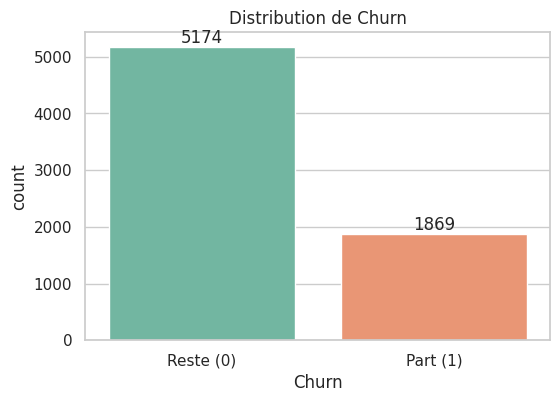

Churn
0    73.5
1    26.5
Name: proportion, dtype: float64


In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df_clean, x="Churn", hue="Churn", palette="Set2", legend=False, ax=ax)
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
ax.set_xticks([0, 1], ["Reste (0)", "Part (1)"])
ax.set_title("Distribution de Churn")
plt.show()
print((df_clean["Churn"].value_counts(normalize=True) * 100).round(1))

**Observation :** ≈ 73,5 % de clients restent, ≈ 26,5 % partent : classes **déséquilibrées**.

**Conséquences pour la suite :**
- L'accuracy sera trompeuse (prédire « personne ne part » donne déjà 73,5 %) : on jugera avec Recall, F1 et ROC-AUC.
- Il faudra `stratify=y` au split, et `class_weight` ou SMOTE (dans le train uniquement).

## C.2 Variables numériques

In [15]:
df_clean[num_cols].describe().round(2)

,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00
mean,32.37,64.76,2279.73
std,24.56,30.09,2266.79
min,0.00,18.25,0.00
25%,9.00,35.50,398.55
50%,29.00,70.35,1394.55
75%,55.00,89.85,3786.60
max,72.00,118.75,8684.80


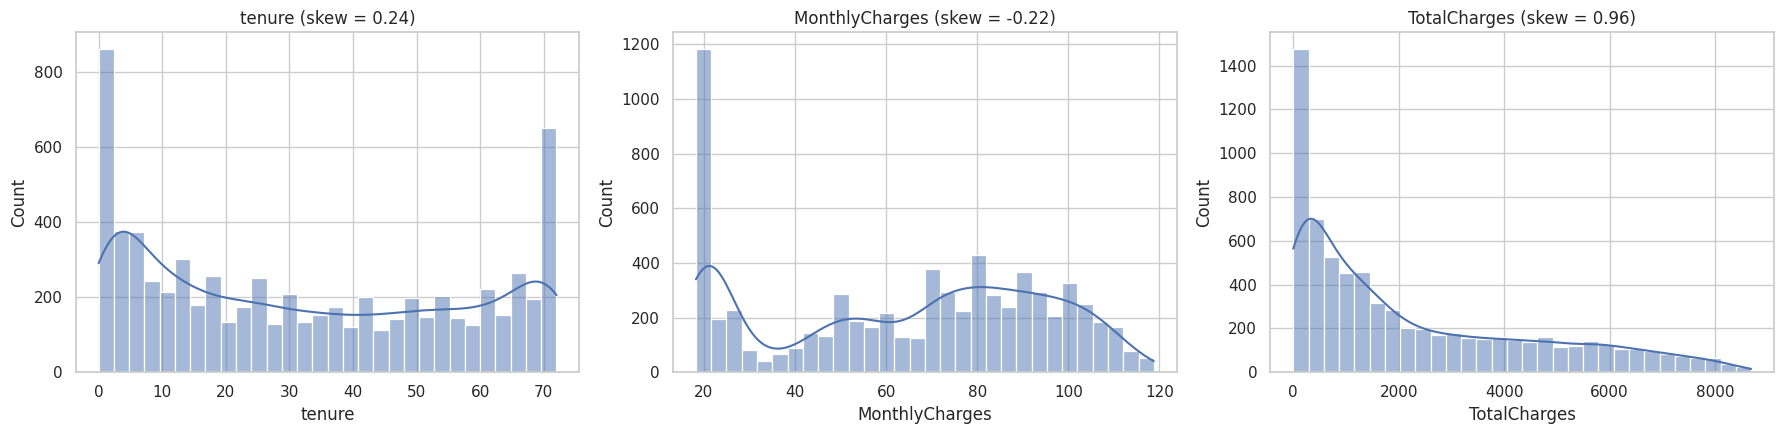

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, col in zip(axes, num_cols):
    sns.histplot(df_clean[col], kde=True, bins=30, ax=ax)
    ax.set_title(f"{col} (skew = {df_clean[col].skew():.2f})")
plt.tight_layout()
plt.show()

**Observations :**
- `tenure` : deux pics, l'un à 1 mois (613 clients) et l'autre à 72 mois (362 clients). Beaucoup de nouveaux clients et une base fidèle, avec peu d'intermédiaires.
- `MonthlyCharges` : un groupe important à faible facture (≈ 20 % des clients paient moins de 25) puis une large bosse plus haut.
- `TotalCharges` : très asymétrique à droite (skew ≈ 0,96), ce qui est normal puisque c'est un cumul (≈ `tenure × MonthlyCharges`).

**Pourquoi c'est utile ?** L'asymétrie de `TotalCharges` peut justifier une transformation (log) ou au moins une standardisation avant K-Means et SVM, sensibles à l'échelle.

## C.3 Outliers (méthode IQR)

{'tenure': 0, 'MonthlyCharges': 0, 'TotalCharges': 0}


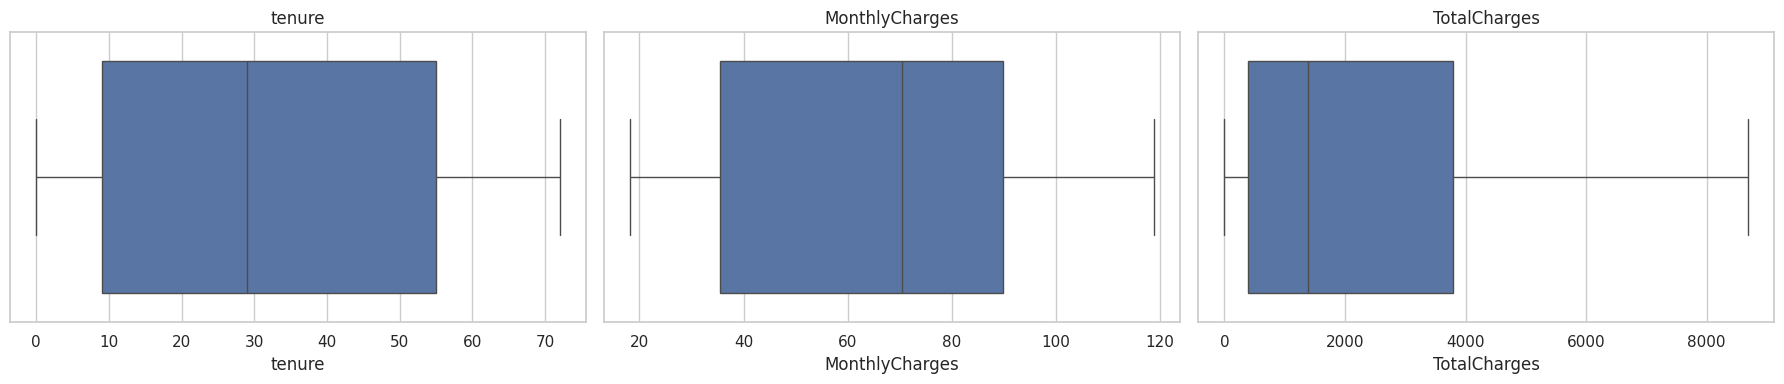

In [17]:
def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return int(((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum())

print({c: iqr_outliers(df_clean[c]) for c in num_cols})

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(x=df_clean[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Pourquoi l'IQR ?** Un point est jugé atypique s'il dépasse de 1,5 × IQR les quartiles Q1/Q3. Cette règle ne suppose pas une distribution normale (contrairement au z-score), ce qui convient à nos variables asymétriques.

**Résultat :** 0 outlier sur les trois variables. **Décision :** aucune suppression ni écrêtage. Même s'il y en avait, un gros client peut être un profil réel à conserver pour le clustering.

## C.4 Variables catégorielles

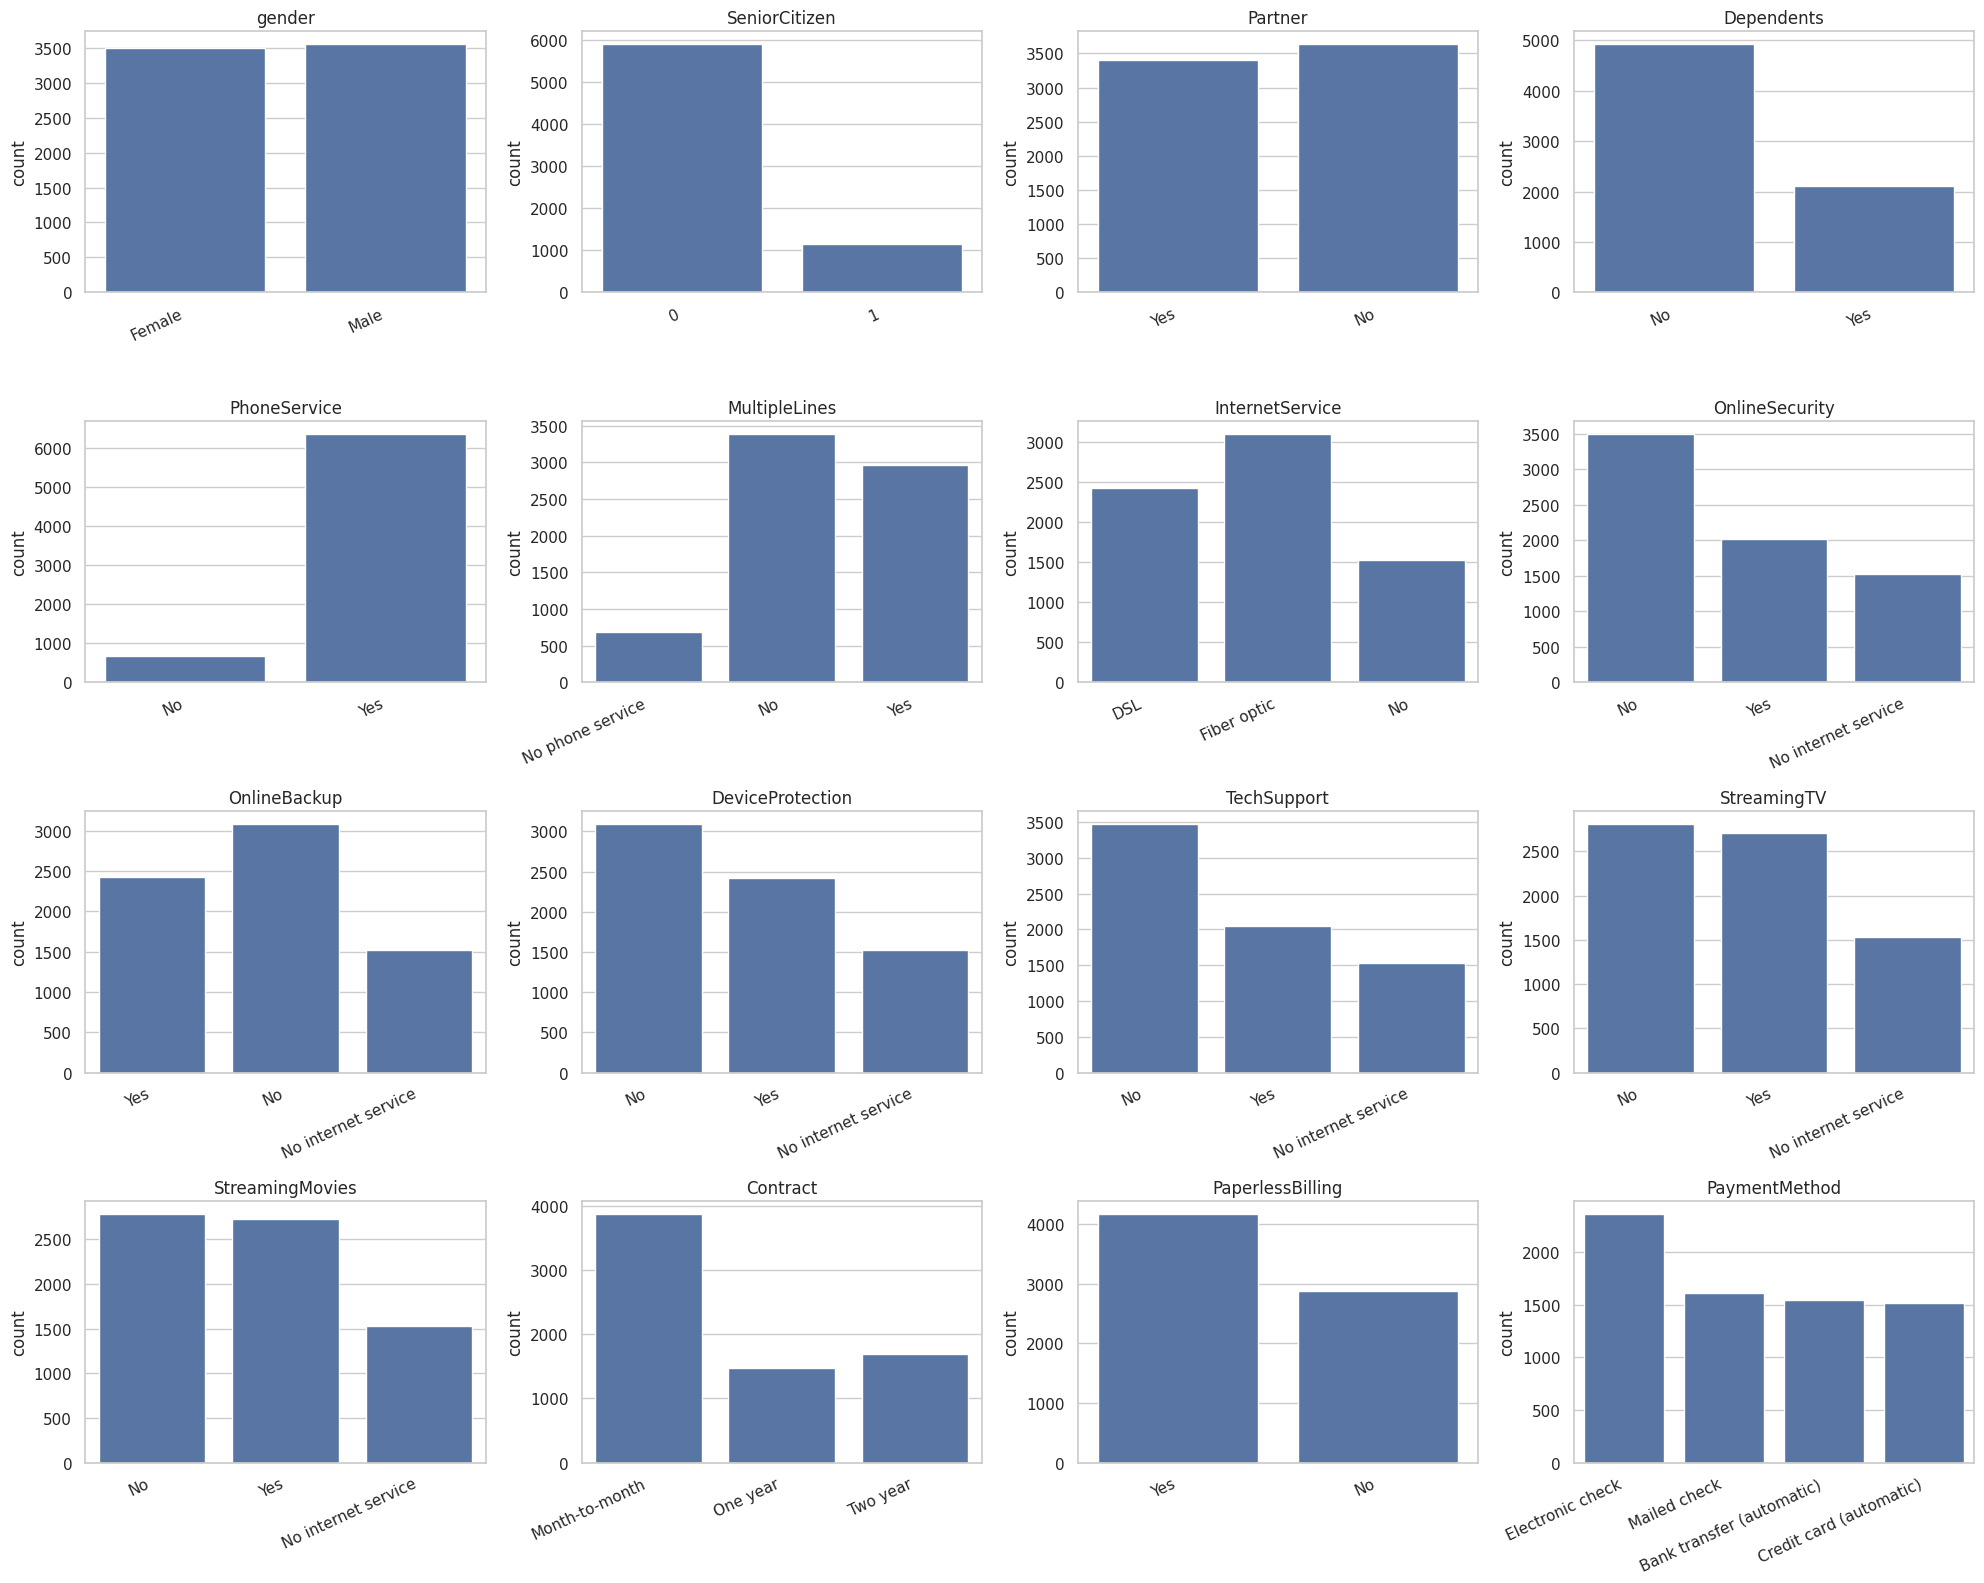

In [18]:
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
for ax, col in zip(axes.ravel(), cat_cols):
    sns.countplot(data=df_clean, x=col, color="#4C72B0", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    plt.setp(ax.get_xticklabels(), rotation=25, ha="right")
plt.tight_layout()
plt.show()

**Pourquoi un graphique par variable ?** On repère les modalités très rares (à regrouper au besoin) et les variables quasi constantes. Ici aucune modalité n'est trop rare. `PhoneService` est très majoritairement « Yes » : elle apportera probablement peu.

### Bilan Partie C
Classes déséquilibrées (26,5 % de churn), aucun outlier, `TotalCharges` asymétrique, `tenure` bimodal.

# Partie D : Analyse bivariée (variables vs churn)

On mesure maintenant comment chaque variable est liée à `Churn`. Pour les catégories, on compare des **taux de churn** (et non des effectifs bruts), sinon un grand groupe paraîtrait toujours « pire » simplement parce qu'il est plus nombreux.

## D.1 Numériques vs churn

tenure        MonthlyCharges        TotalCharges        
        mean median           mean median         mean  median
Churn                                                         
0       37.6   38.0           61.3   64.4       2549.9  1679.5
1       18.0   10.0           74.4   79.6       1531.8   703.6

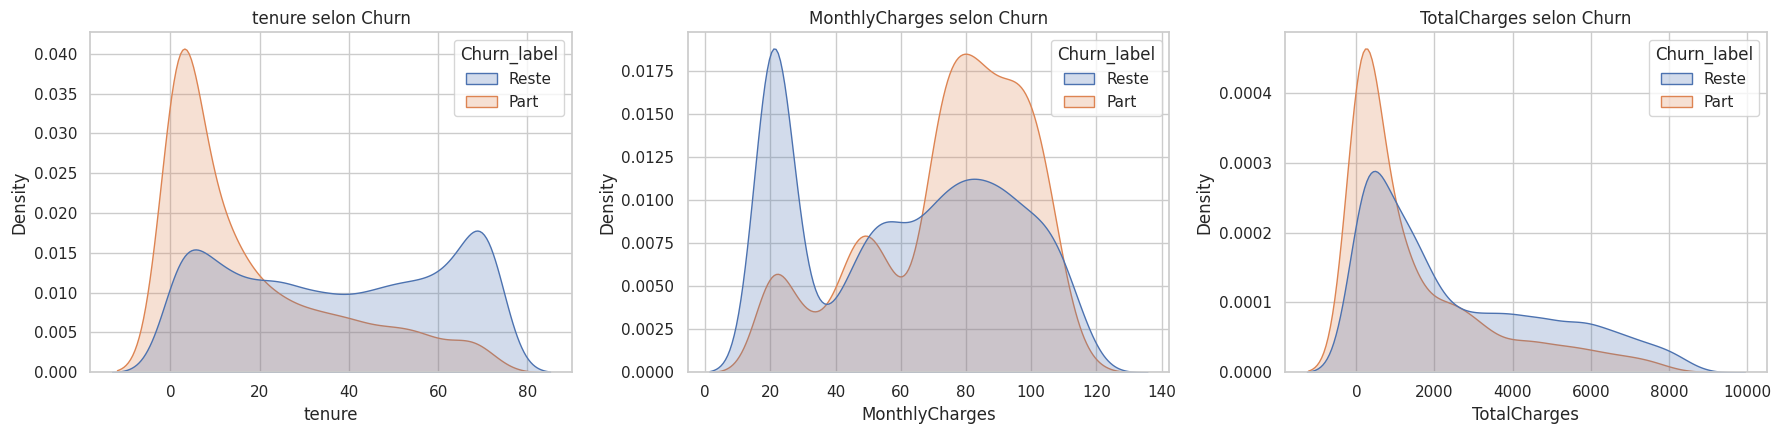

In [19]:
df_eda = df_clean.assign(Churn_label=df_clean["Churn"].map({0: "Reste", 1: "Part"}))
display(df_clean.groupby("Churn")[num_cols].agg(["mean", "median"]).round(1))

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, col in zip(axes, num_cols):
    sns.kdeplot(data=df_eda, x=col, hue="Churn_label", common_norm=False, fill=True,
                palette={"Reste": "#4C72B0", "Part": "#DD8452"}, ax=ax)
    ax.set_title(f"{col} selon Churn")
plt.tight_layout()
plt.show()

**Pourquoi `common_norm=False` ?** Chaque courbe est normalisée séparément : sinon la classe majoritaire écraserait visuellement la classe qui part.

**Observations :**
- `tenure` : médiane de **10 mois** chez ceux qui partent contre **38** chez ceux qui restent. Le churn se joue surtout au début de la vie du client.
- `MonthlyCharges` : médiane plus élevée pour les partants (≈ 80 contre ≈ 64).
- `TotalCharges` : plus bas pour les partants, mais c'est surtout un effet mécanique de la faible ancienneté.

,mean,size
tenure_group,,
0-12,0.474,2186
13-24,0.287,1024
25-48,0.204,1594
49-72,0.095,2239


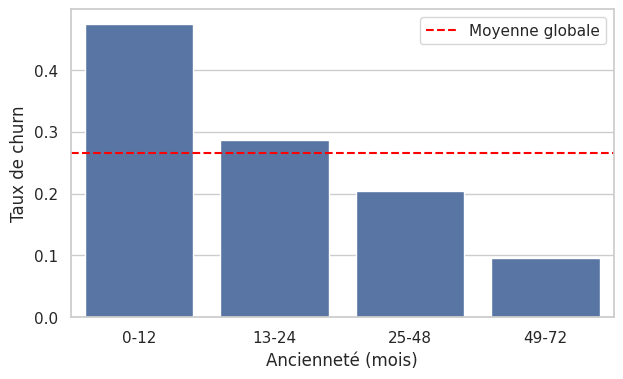

In [20]:
df_eda["tenure_group"] = pd.cut(df_eda["tenure"], bins=[-1, 12, 24, 48, 72],
                                labels=["0-12", "13-24", "25-48", "49-72"])
rate = df_eda.groupby("tenure_group", observed=True)["Churn"].agg(["mean", "size"])
display(rate.round(3))

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=rate.index.astype(str), y=rate["mean"], color="#4C72B0", ax=ax)
ax.axhline(df_clean["Churn"].mean(), color="red", ls="--", label="Moyenne globale")
ax.set_ylabel("Taux de churn"); ax.set_xlabel("Ancienneté (mois)")
ax.legend(); plt.show()

**Pourquoi découper `tenure` en tranches ?** Cela rend la relation lisible : le churn passe de **≈ 47 %** la première année à **≈ 9,5 %** après 4 ans. Cette relation non linéaire donnera une variable `tenure_group` candidate au Feature Engineering.

## D.2 Catégorielles vs churn

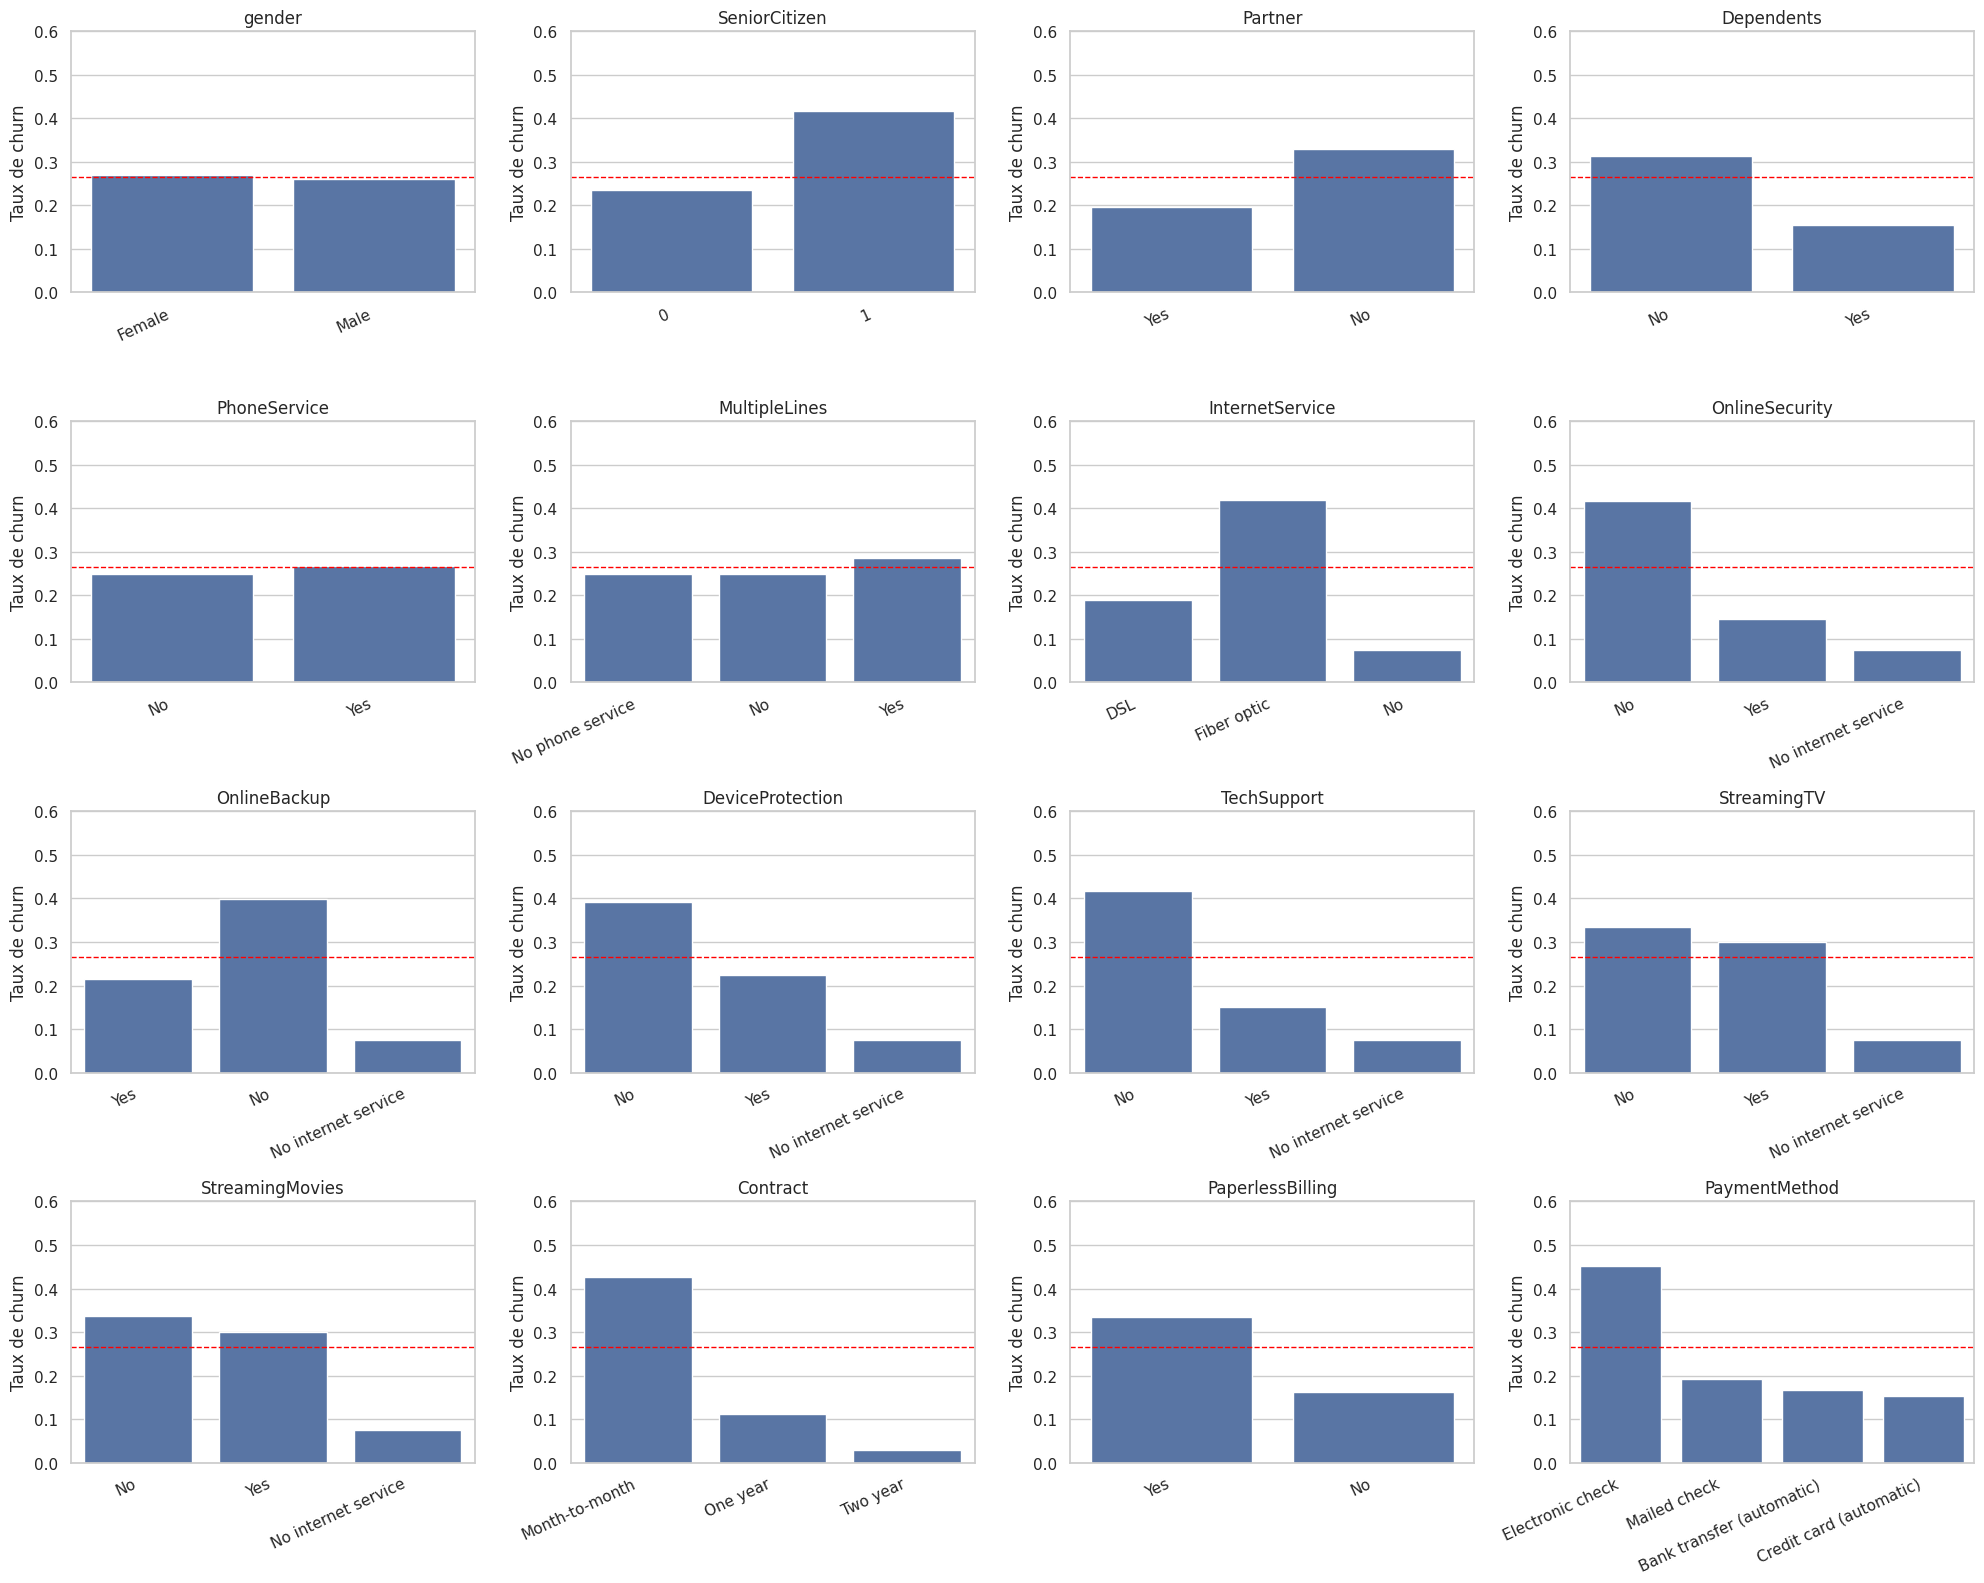

In [21]:
global_rate = df_clean["Churn"].mean()
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
for ax, col in zip(axes.ravel(), cat_cols):
    sns.barplot(data=df_clean, x=col, y="Churn", errorbar=None, color="#4C72B0", ax=ax)
    ax.axhline(global_rate, color="red", ls="--", lw=1)
    ax.set_ylim(0, 0.6)
    ax.set_title(col); ax.set_xlabel(""); ax.set_ylabel("Taux de churn")
    plt.setp(ax.get_xticklabels(), rotation=25, ha="right")
plt.tight_layout()
plt.show()

La ligne rouge est le taux global (26,5 %). Une barre au-dessus = groupe à risque.

**Observations principales :**
- `Contract` : mensuel **42,7 %**, 1 an **11,3 %**, 2 ans **2,8 %**. C'est le facteur le plus discriminant.
- `InternetService` : fibre **41,9 %**, DSL **19,0 %**, sans internet **7,4 %**.
- `PaymentMethod` : chèque électronique **45,3 %**, contre 15 à 19 % pour les autres modes.
- `OnlineSecurity` et `TechSupport` : sans le service ≈ **42 %**, avec ≈ **15 %**.
- `SeniorCitizen` : 41,7 % contre 23,6 %. `PaperlessBilling`, `Partner`, `Dependents` : écart modéré.
- `gender`, `PhoneService`, `MultipleLines` : taux quasi identiques d'une modalité à l'autre, donc peu informatifs.

## D.3 Classer les variables catégorielles (V de Cramér)

,Cramér's V
Contract,0.410
OnlineSecurity,0.347
TechSupport,0.343
InternetService,0.322
PaymentMethod,0.303
OnlineBackup,0.292
DeviceProtection,0.282
StreamingMovies,0.231
StreamingTV,0.231
PaperlessBilling,0.191


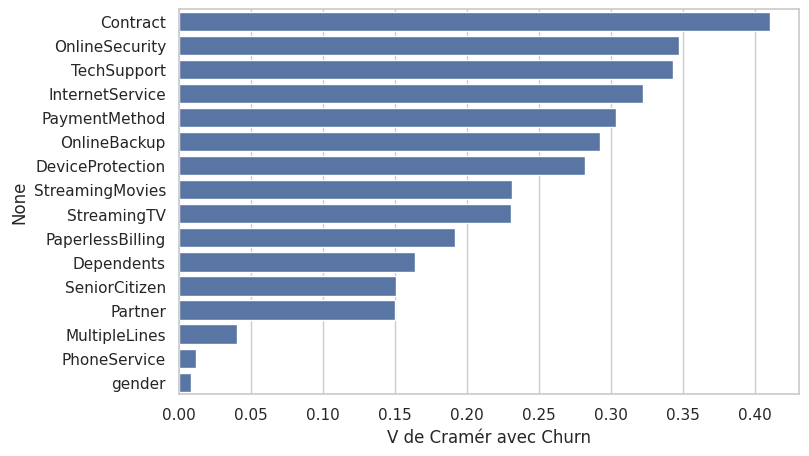

In [22]:
def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = table.values.sum()
    return np.sqrt(chi2 / (n * (min(table.shape) - 1)))

cv = pd.Series({c: cramers_v(df_clean[c], df_clean["Churn"]) for c in cat_cols}).sort_values(ascending=False)
display(cv.round(3).to_frame("Cramér's V"))

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=cv.values, y=cv.index, color="#4C72B0", ax=ax)
ax.set_xlabel("V de Cramér avec Churn"); plt.show()

**Pourquoi le V de Cramér ?** C'est une mesure d'association entre deux variables catégorielles, comprise entre 0 (aucun lien) et 1 (lien parfait). Elle classe les variables avec un seul chiffre, ce que la corrélation de Pearson ne peut pas faire pour du texte.

**Résultat :** `Contract` (0,41) domine, suivi de `OnlineSecurity`, `TechSupport`, `InternetService` et `PaymentMethod` (≈ 0,30 à 0,35). `gender` (0,008) et `PhoneService` (0,011) sont proches de 0. Ce classement est indicatif, pas une règle de suppression : on laissera les modèles et la validation croisée trancher.

## D.4 Corrélations numériques

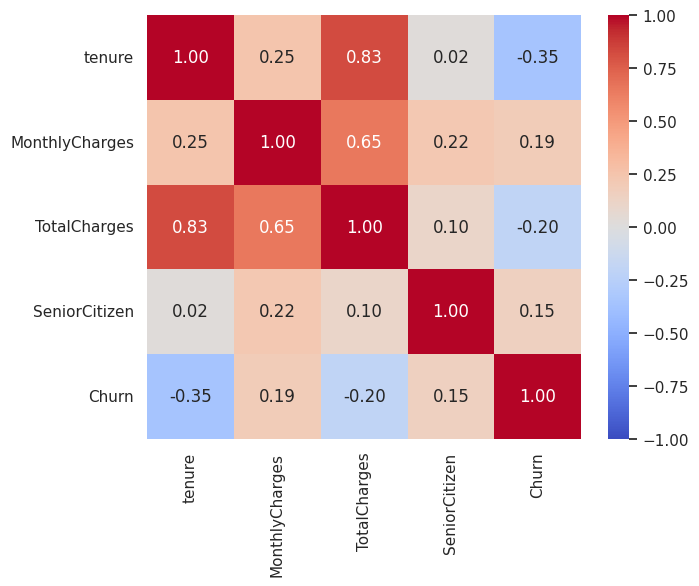

In [23]:
corr = df_clean[["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "Churn"]].corr()
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, center=0, ax=ax)
plt.show()

**Observations :**
- `tenure` ↔ `Churn` : **−0,35**, le lien numérique le plus fort avec la cible (plus on est ancien, moins on part).
- `tenure` ↔ `TotalCharges` : **0,83**. Ces deux variables sont **redondantes** : problématique pour la régression logistique (multicolinéarité) et pour le clustering, qui compterait deux fois la même information.
- `MonthlyCharges` ↔ `Churn` : +0,19, lien modeste.

**Pourquoi ne pas mettre les catégories dans cette matrice ?** Pearson n'a de sens que pour des variables quantitatives ; c'est pour cela qu'on a utilisé le V de Cramér en D.3.

## D.5 Pistes de Feature Engineering (à implémenter en J3)
| Idée | Raison |
|---|---|
| `tenure_group` (tranches) | Relation non linéaire entre ancienneté et churn |
| `n_services` (nombre de services souscrits) | Résume 6 colonnes de services en un signal |
| `avg_monthly_paid = TotalCharges / tenure` | Compare le tarif actuel au tarif historique (attention à `tenure = 0`) |
| `is_month_to_month` | Le contrat mensuel concentre le risque |
| `auto_payment` (prélèvement automatique) | Le chèque électronique est le mode le plus à risque |
| Fusion de `No internet service` / `No phone service` en `No` | Éviter les colonnes redondantes après encodage |

Ces variables seront créées **dans un `Pipeline`** ou une fonction de `src/`, pour rester reproductibles côté Streamlit.

# Bilan général de l'EDA
1. **Données propres** : un seul défaut réel (`TotalCharges` vide pour les clients neufs), corrigé par une règle métier sans leakage.
2. **Cible déséquilibrée** (26,5 %) : métriques adaptées, `stratify`, `class_weight` / SMOTE dans le train seulement.
3. **Profil du client qui part** : contrat mensuel, ancienneté faible (médiane 10 mois), fibre optique, chèque électronique, pas de sécurité en ligne ni de support technique, facture mensuelle plus élevée.
4. **Redondance** : `tenure` et `TotalCharges` très corrélées (0,83) ; à surveiller.
5. **Variables peu utiles** a priori : `gender`, `PhoneService`, `MultipleLines`.
6. **Prochaine étape (J3)** : encodage, standardisation, Feature Engineering, split train/test et `Pipeline`.